In [1]:
# Imports
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hysys import open_case
from hysys_pfr import cache_objects, run_point
from helpers import generate_sobol_points, fit_mlp, cross_validate, select_width

In [2]:
CASE = r"C:\Users\kr326\Documents\Andrea_Files_MeOH_Aspen\TestAspenFile\PFR.hsc"
t0 = time.time()
case = open_case(CASE)

print(f"Case name:        {case.Name}")
print(f"Material streams: {case.Flowsheet.MaterialStreams.Count}")
print(f"Connected in      {time.time() - t0:.1f} s")

# Cache flowsheet objects
objects = cache_objects(case)
print("Objects cached OK:")
for k in objects:
    print(f"  {k}")

Case name:        Case
Material streams: 2
Connected in      0.0 s
Objects cached OK:
  solver
  rin
  rout
  reactor
  components


In [3]:
# KNOBS
SMOKE_TEST = False
VOLUME = 35                     # m3, fixed reactor design
FLOW_UNIT = "kgmole/s"          # unit of the flow bounds below

# Design box; key order defines the sampler's x.  T and P are the loop's design
# variables.  The six flows are the inlet hull the loop sends to the reactor
# (U_Hull from surrogate_decomposition), inflated by INFLATE on both sides so the
# net is not asked to extrapolate at the edges of the design box.
INFLATE = 0.15
U_HULL = {                       # kgmole/s
    'Hydrogen': [2.115631825485868, 4.683309458965791],
    'CO': [0.03363474278468826, 0.24530105260839788],
    'CO2': [0.40419114689316316, 1.1712367732290734],
    'H2O': [0.007896525305531005, 0.010121515559163982],
    'Methanol': [0.003404552545371686, 0.012608897743876114],
    'Nitrogen': [0.056309686994445524, 0.0588813310245413],
}
pfr_inlet_bounds = {'temperature_C': [220, 280], 'pressure_bar': [70, 120],
                    **{c: [lo * (1 - INFLATE), hi * (1 + INFLATE)] for c, (lo, hi) in U_HULL.items()}}
import json
json.dump(pfr_inlet_bounds, open("pfr_box.json", "w"), indent=1)      # read by hysys_surrogate

# number of points to be evaluated on PFR
N_PTS = 64 if SMOKE_TEST else 1024

In [4]:
# Interface adapter: sampler vector -> HYSYS -> one flat result row
FLOW_NAMES = [k for k in pfr_inlet_bounds if k in objects["components"]]

def pfr_row(x):
    """NOTE: Ensure that x is in pfr_inlet_bounds order."""
    assert len(x)==len(pfr_inlet_bounds)
    p = dict(zip(pfr_inlet_bounds, x))
    return run_point(objects, temperature=(p["temperature_C"], "C"),
                     pressure=(p["pressure_bar"], "bar"), volume=(VOLUME, "m3"),
                     flows=({c: p[c] for c in FLOW_NAMES}, FLOW_UNIT))

In [5]:
def unit_sobol_sample(bounds, model, n_pts):
    lb = np.array([b[0] for b in bounds.values()])
    ub = np.array([b[1] for b in bounds.values()])
    input_var = generate_sobol_points(n=n_pts, bounds=np.stack((lb, ub)))
    results = []

    for iv in input_var:
        res = {**dict(zip(bounds, iv)), **model(iv)}
        results.append(res)

    return pd.DataFrame(results)

In [6]:
t0 = time.time()
df = unit_sobol_sample(bounds=pfr_inlet_bounds, model=pfr_row, n_pts=N_PTS)

print(f"{len(df)} evaluations, {time.time() - t0:.0f} s")
df.to_csv(f"pfr_sobol{'_smoke' if SMOKE_TEST else ''}.csv", index=False)

1024 evaluations, 36 s


[Text(0.5, 0, 'T [$^\\circ{C}$]'), Text(0, 0.5, 'Pressure [bar]')]

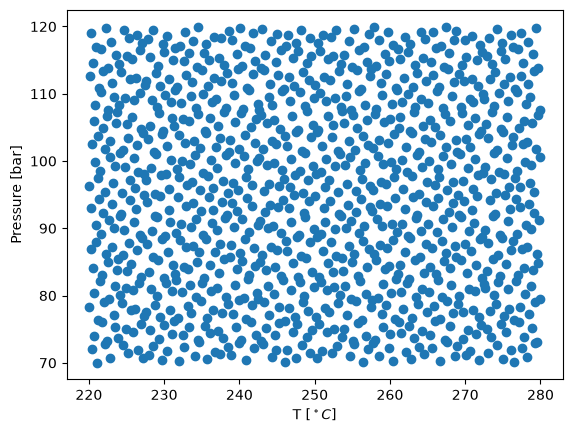

In [7]:
# Sampled design points in the T-P plane; the six flow dimensions are projected out
fig, ax = plt.subplots()
ax.scatter(df.temperature_C, df.pressure_bar)
ax.set(xlabel="T [$^\\circ{C}$]", ylabel="Pressure [bar]")

In [8]:
# Two surrogates of the same reactor, trained on the same inputs:
#   stoi: predicts the extents of the two independent reactions
#           xi1: CO2 + 3 H2 -> CH3OH + H2O      xi2: CO2 + H2 -> CO + H2O
#         plus duty and pressure drop; outlet = inlet + stoichiometry * extents,
#         so the atom balances hold by construction.
#   raw:  predicts the six outlet flows plus duty and pressure drop directly.
COMPONENTS = ["Hydrogen", "CO", "CO2", "H2O", "Methanol", "Nitrogen"]      # the ones that reach the reactor
STOICH = {"Hydrogen": (-3, -1), "CO": (0, 1), "CO2": (-1, -1),
          "H2O": (1, 1), "Methanol": (1, 0), "Nitrogen": (0, 0)}           # (nu_xi1, nu_xi2)

def outlet_flows(inlet_kgmole_h: dict, xi) -> dict:
    """Outlet component flows from inlet flows and the two extents [kgmole/h]."""
    return {c: inlet_kgmole_h[c] + a * xi[0] + b * xi[1] for c, (a, b) in STOICH.items()}

ok = df[df["converged"]]
X = ok[list(pfr_inlet_bounds)].to_numpy()                 # inputs in box order
Y_stoi = pd.DataFrame({
    "xi_meoh_kgmole_h": ok.out_Methanol_kgmole_h - ok.in_Methanol_kgmole_h,
    "xi_co_kgmole_h":   ok.out_CO_kgmole_h - ok.in_CO_kgmole_h,
    "reactor_duty_kW":  ok.reactor_duty_kW,
    "reactor_dP_bar":   ok.reactor_dP_bar,
})
Y_raw = pd.concat([ok[[f"out_{c}_kgmole_h" for c in COMPONENTS]],
                   ok[["reactor_duty_kW", "reactor_dP_bar"]]], axis=1)
print(f"{len(X)} training points, {X.shape[1]} inputs -> stoi {Y_stoi.shape[1]} outputs, raw {Y_raw.shape[1]} outputs")

1024 training points, 8 inputs -> stoi 4 outputs, raw 8 outputs


In [9]:
def train_surrogate(X, Y: pd.DataFrame, name: str):
    """Width search, 5-fold CV report, final fit on all data, export.  Returns (model, rmse, Y_oof)."""
    t0 = time.time()
    width, table = select_width(X, Y.to_numpy(), verbose=False)
    rmse, Y_oof = cross_validate(X, Y.to_numpy(), hidden=width)
    model = fit_mlp(X, Y.to_numpy(), hidden=width)
    model.export(f"pfr_surrogate_{name}.txt")
    print(f"=== {name}: width {width} ({time.time() - t0:.0f} s)   CV rmse/std per width: "
          + ", ".join(f"{w}: {v:.4f}" for w, v in table.items()))
    for col, r, span in zip(Y.columns, rmse, Y.max() - Y.min()):
        print(f"  {col:22s} {r:9.3f}   {100 * r / span:5.2f} % of range")
    return model, rmse, Y_oof

stoi, rmse_stoi, oof_stoi = train_surrogate(X, Y_stoi, "stoi")
raw, rmse_raw, oof_raw = train_surrogate(X, Y_raw, "raw")

=== stoi: width 64 (49 s)   CV rmse/std per width: 4: 0.0763, 8: 0.0383, 16: 0.0138, 32: 0.0094, 64: 0.0081, 128: 0.0109
  xi_meoh_kgmole_h           2.299    0.18 % of range
  xi_co_kgmole_h             1.734    0.18 % of range
  reactor_duty_kW           49.767    0.18 % of range
  reactor_dP_bar             0.001    0.11 % of range
=== raw: width 64 (50 s)   CV rmse/std per width: 4: 0.3579, 8: 0.0868, 16: 0.0304, 32: 0.0162, 64: 0.0089, 128: 0.0094
  out_Hydrogen_kgmole_h     16.585    0.16 % of range
  out_CO_kgmole_h            1.777    0.26 % of range
  out_CO2_kgmole_h           4.847    0.16 % of range
  out_H2O_kgmole_h           2.276    0.20 % of range
  out_Methanol_kgmole_h      2.364    0.19 % of range
  out_Nitrogen_kgmole_h      0.018    0.19 % of range
  reactor_duty_kW           53.081    0.19 % of range
  reactor_dP_bar             0.002    0.15 % of range


out-of-fold RMSE of outlet flows [kgmole/h]:
             range  stoi_rmse  raw_rmse
Hydrogen  10294.86       6.57     16.59
CO          689.20       1.73      1.78
CO2        3014.02       2.42      4.85
H2O        1166.57       2.42      2.28
Methanol   1264.56       2.30      2.36
Nitrogen      9.25       0.00      0.02

raw net atom balance error, out minus in [kgmole/h]  (stoi: zero by construction):
  C: rms    4.51   max   23.50
  O: rms    8.71   max   46.12
  H: rms   32.90   max  229.65


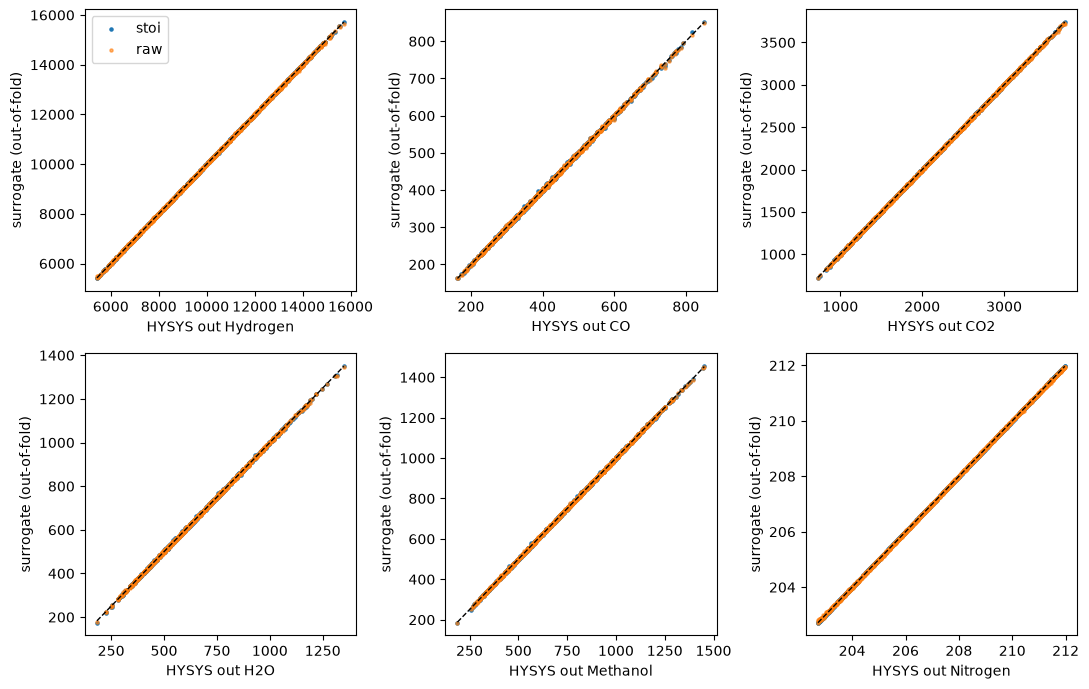

In [10]:
# Side by side on the same footing: outlet flows, with the stoi outlets rebuilt
# from its out-of-fold extents, and the atom balances of the raw net's outlets.
inlet = ok[[f"in_{c}_kgmole_h" for c in COMPONENTS]].to_numpy()
outlet = ok[[f"out_{c}_kgmole_h" for c in COMPONENTS]].to_numpy()
NU = np.array([STOICH[c] for c in COMPONENTS], float)              # (6, 2)
out_stoi = inlet + oof_stoi[:, :2] @ NU.T
comparison = pd.DataFrame({
    "range": outlet.max(0) - outlet.min(0),
    "stoi_rmse": np.sqrt(((out_stoi - outlet) ** 2).mean(0)),
    "raw_rmse": np.sqrt(((oof_raw[:, :6] - outlet) ** 2).mean(0)),
}, index=COMPONENTS).round(2)
print("out-of-fold RMSE of outlet flows [kgmole/h]:")
print(comparison)

ATOMS = {"C": [0, 1, 1, 0, 1, 0], "O": [0, 1, 2, 1, 1, 0], "H": [2, 0, 0, 2, 4, 0]}   # per COMPONENTS
print()
print("raw net atom balance error, out minus in [kgmole/h]  (stoi: zero by construction):")
for atom, v in ATOMS.items():
    err = (oof_raw[:, :6] - inlet) @ np.array(v, float)
    print(f"  {atom}: rms {np.sqrt((err ** 2).mean()):7.2f}   max {np.abs(err).max():7.2f}")

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, c, y, a, b in zip(axes.flat, COMPONENTS, outlet.T, out_stoi.T, oof_raw[:, :6].T):
    ax.scatter(y, a, s=5, label="stoi")
    ax.scatter(y, b, s=5, label="raw", alpha=0.6)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=1)
    ax.set(xlabel=f"HYSYS out {c}", ylabel="surrogate (out-of-fold)")
axes.flat[0].legend()
fig.tight_layout()

In [11]:
# Sanity check on one point: both surrogates against HYSYS
row = ok.iloc[0]
x = row[list(pfr_inlet_bounds)].to_numpy()
from_stoi = outlet_flows({c: row[f"in_{c}_kgmole_h"] for c in COMPONENTS}, stoi(x))
from_raw = dict(zip(COMPONENTS, raw(x)))
for c in COMPONENTS:
    print(f"  {c:9s} HYSYS {row[f'out_{c}_kgmole_h']:9.2f}   stoi {from_stoi[c]:9.2f}   raw {from_raw[c]:9.2f} kgmole/h")

  Hydrogen  HYSYS  13071.89   stoi  13072.83   raw  13058.51 kgmole/h
  CO        HYSYS    297.16   stoi    296.94   raw    295.99 kgmole/h
  CO2       HYSYS   1521.41   stoi   1521.85   raw   1523.79 kgmole/h
  H2O       HYSYS    791.55   stoi    791.11   raw    790.09 kgmole/h
  Methanol  HYSYS    656.47   stoi    656.21   raw    656.33 kgmole/h
  Nitrogen  HYSYS    208.31   stoi    208.31   raw    208.31 kgmole/h
